# Import Modules

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf

# For Loading Dataset
from tensorflow.keras.utils import image_dataset_from_directory

# For Data Normalization
from tensorflow.keras.layers import Rescaling

# For Data Argmentation
from tensorflow.keras import layers

# For Build Layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import mobilenet_v2

# For Evaluation
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

---

# Load Dataset

In [120]:
# Define Image Size

image_height = 224
image_width = 224

## Eye Dataset

In [121]:
# Training Dataset
eye_train_dataset = image_dataset_from_directory(
    "../datasets/train/eye_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=True
)

# Validation Dataset
eye_validation_dataset = image_dataset_from_directory(
    "../datasets/validation/eye_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

# Test Dataset
eye_test_dataset = image_dataset_from_directory(
    "../datasets/test/eye_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

Found 1016 files belonging to 2 classes.


Found 216 files belonging to 2 classes.
Found 220 files belonging to 2 classes.


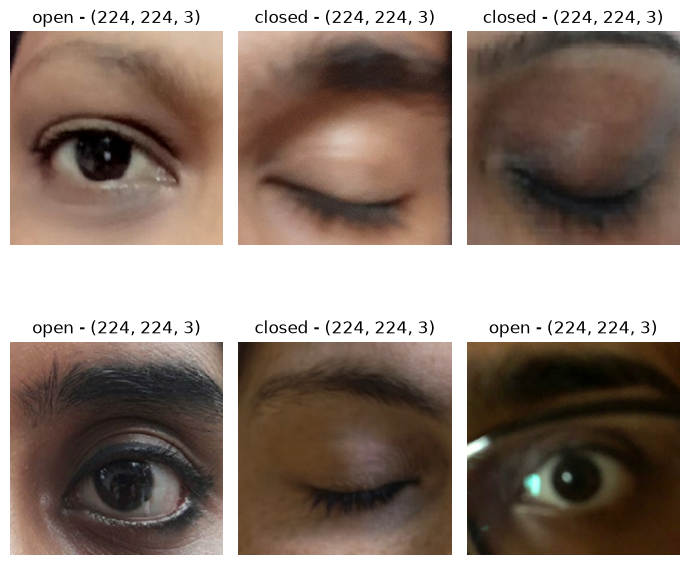

In [122]:
# Visual Sample Images

plt.figure(figsize=(7,7))

for images, labels in eye_train_dataset.take(1):
    
    for i in range(1, 7):
        
        image = images[i].numpy().astype("uint8")
        
        index = np.argmax(labels[i])
        
        class_name = eye_train_dataset.class_names[index]
        
        plt.subplot(2,3, i)
        
        plt.imshow(image)
        
        plt.title(f"{class_name} - {image.shape}")
        
        plt.axis("off")
        
plt.tight_layout()
plt.show()

## Mouth Dataset

In [123]:
# Training Dataset
mouth_train_dataset = image_dataset_from_directory(
    "../datasets/train/mouth_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=True
)

# Validation Dataset
mouth_validation_dataset = image_dataset_from_directory(
    "../datasets/validation/mouth_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

# Test Dataset
mouth_test_dataset = image_dataset_from_directory(
    "../datasets/test/mouth_dataset",
    label_mode = "categorical",
    batch_size=32,
    image_size = (image_height, image_width),
    shuffle=False
)

Found 1013 files belonging to 2 classes.
Found 216 files belonging to 2 classes.
Found 219 files belonging to 2 classes.


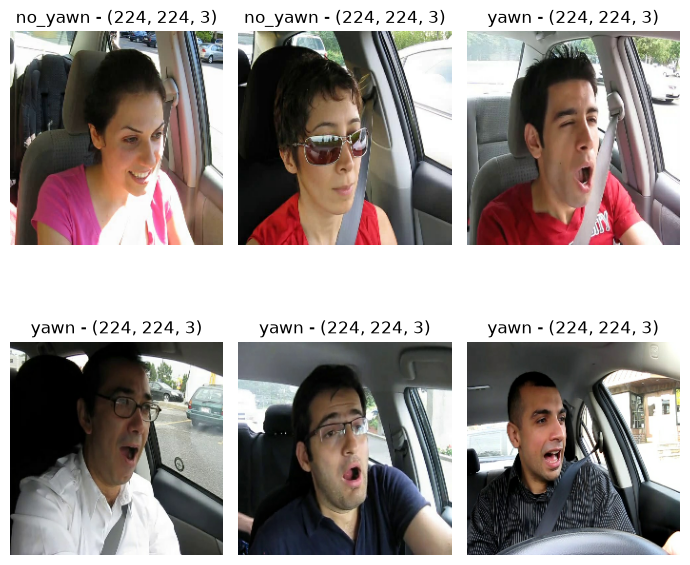

In [124]:
# Visual Sample Images
plt.figure(figsize=(7,7))

for images, labels in mouth_train_dataset.take(1):
    
    for i in range(1, 7):
        
        image = images[i].numpy().astype("uint8")
        
        index = np.argmax(labels[i])
        
        class_name = mouth_train_dataset.class_names[index]
        
        plt.subplot(2,3, i)
        
        plt.imshow(image)
        
        plt.title(f"{class_name} - {image.shape}")
        
        plt.axis("off")
        
plt.tight_layout()
plt.show()

---

# Data Argmentation

In [125]:
data_argmentation = Sequential([
    
    layers.RandomZoom(0.1),
    
    layers.RandomRotation(0.1),
    
    layers.RandomBrightness(0.1),
    
    layers.RandomFlip("horizontal")
])

---

# Model Training

## Eye Model Implement - MobileNetV2

In [126]:
base_model_eye = mobilenet_v2.MobileNetV2(
    input_shape = (224, 224, 3),
    include_top=False,
    weights='imagenet'
)

In [127]:
base_model_eye.trainable = False

In [128]:
eye_model = Sequential([
    
    # Input Layer
    layers.Input(shape=(image_height, image_width, 3)),
    
    # Data Argmentation
    data_argmentation,
    
    # Preprocessing Layer
    layers.Lambda(mobilenet_v2.preprocess_input),
    
    # MobileNetV2 Model
    base_model_eye,
    
    # Poooling Layer
    layers.GlobalAveragePooling2D(),
    
    # Hidden Layer 1
    layers.Dense(units = 128, activation = "relu"),
    
    # Dropout Layer
    layers.Dropout(0.4),
    
    # Output Layer
    layers.Dense(units = 2, activation = "softmax")
])

In [129]:
eye_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [130]:
eye_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [131]:
eye_model_history = eye_model.fit(
    eye_train_dataset,
    validation_data=eye_validation_dataset,
    epochs=20
)

Epoch 1/20


/home/jeeva/miniconda3/envs/tf-gpu-conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.9163 - loss: 0.2064 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9803 - loss: 0.0430 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9902 - loss: 0.0273 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9951 - loss: 0.0147 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9892 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9931 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9902 - loss: 0.0207 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9970 - loss: 0.0108 - val_accuracy: 0.9907 - val_loss: 0

---

### Accuracy, Loss Plot

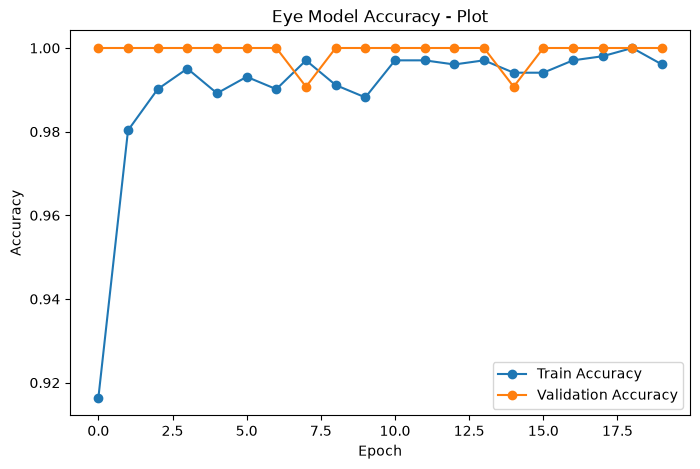

In [132]:
plt.figure(figsize=(8,5))

plt.plot(
    eye_model_history.history["accuracy"],
    label = "Train Accuracy",
    marker = "o"
)

plt.plot(eye_model_history.history["val_accuracy"],
         label = "Validation Accuracy",
    marker = "o"
)

plt.title("Eye Model Accuracy - Plot")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()     

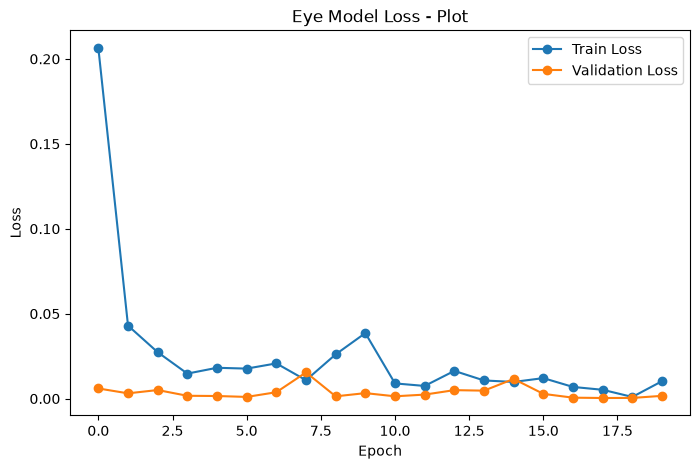

In [133]:
plt.figure(figsize=(8,5))

plt.plot(
    eye_model_history.history["loss"],
    label = "Train Loss",
    marker = "o"
)

plt.plot(eye_model_history.history["val_loss"],
         label = "Validation Loss",
    marker = "o"
)

plt.title("Eye Model Loss - Plot")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()     

---

### Evaluate - Test Data

In [134]:
eye_test_loss, eye_test_accuracy = eye_model.evaluate(eye_test_dataset)

print("Test Accuracy: ", eye_test_accuracy)
print("Test Loss: ", eye_test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9955 - loss: 0.0136
Test Accuracy:  0.9954545497894287
Test Loss:  0.013581966981291771


---

### Prediction - Test Data

In [135]:
eye_predicted = eye_model.predict(eye_test_dataset)

eye_predicted_classes = np.argmax(eye_predicted, axis=1)

eye_predicted_classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 387ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [136]:
eye_actual_classes = np.concatenate([np.argmax(labels, axis=1) for images, labels in eye_test_dataset])

eye_actual_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

---

### Confusion Matrix

In [137]:
eye_c_matrix = confusion_matrix(
    eye_actual_classes, 
    eye_predicted_classes,
)

Text(0, 0.5, 'Actual Label')

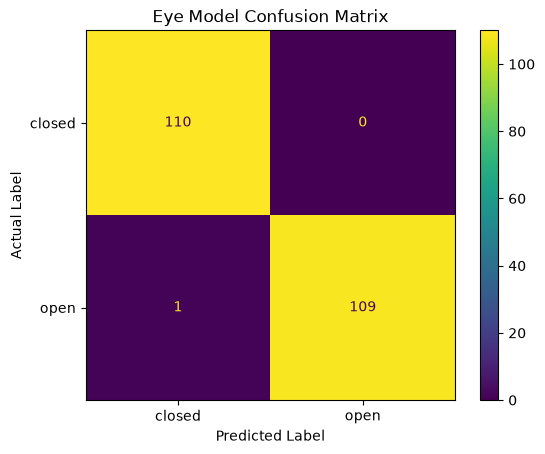

In [138]:
ConfusionMatrixDisplay(
    eye_c_matrix,
    display_labels=eye_test_dataset.class_names
).plot()

plt.title("Eye Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

---

### Classification Report

In [139]:
print(
    classification_report(
        eye_actual_classes, 
        eye_predicted_classes, 
        target_names=eye_test_dataset.class_names
    )
)

              precision    recall  f1-score   support

      closed       0.99      1.00      1.00       110
        open       1.00      0.99      1.00       110

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



---

## Mouth Model Implement - Mobilenetv2

In [140]:
base_model_mouth = mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

In [141]:
base_model_mouth.trainable = False

In [142]:
mouth_model = Sequential([
    
    # Input Layer
    layers.Input(shape=(image_height, image_width, 3)),
    
    # Data Argmentation
    data_argmentation,
    
    # Preprocessing Layer
    layers.Lambda(mobilenet_v2.preprocess_input),
    
    # MobileNetV2 Model
    base_model_mouth,
    
    # Poooling Layer
    layers.GlobalAveragePooling2D(),
    
    # Hidden Layer 1
    layers.Dense(units = 128, activation = "relu"),
    
    # Dropout Layer
    layers.Dropout(0.4),
    
    # Output Layer
    layers.Dense(units = 2, activation = "softmax")
])

In [143]:
mouth_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [144]:
mouth_model_history = mouth_model.fit(
    mouth_train_dataset,
    validation_data = mouth_validation_dataset,
    epochs = 50
)

Epoch 1/50


/home/jeeva/miniconda3/envs/tf-gpu-conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.5982 - loss: 0.7405 - val_accuracy: 0.6528 - val_loss: 0.5956
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.6792 - loss: 0.5523 - val_accuracy: 0.6481 - val_loss: 0.6016
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7029 - loss: 0.5458 - val_accuracy: 0.6435 - val_loss: 0.6224
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7315 - loss: 0.5125 - val_accuracy: 0.6620 - val_loss: 0.6304
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7463 - loss: 0.4795 - val_accuracy: 0.6574 - val_loss: 0.6183
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.7680 - loss: 0.4637 - val_accuracy: 0.6806 - val_loss: 0.6535
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.7453 - loss: 0.4780 - val_accuracy: 0.6852 - val_loss: 0.6183
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.7917 - loss: 0.4328 - val_accuracy: 0.6713 - val_loss

---

### Accuracy, Loss Plot

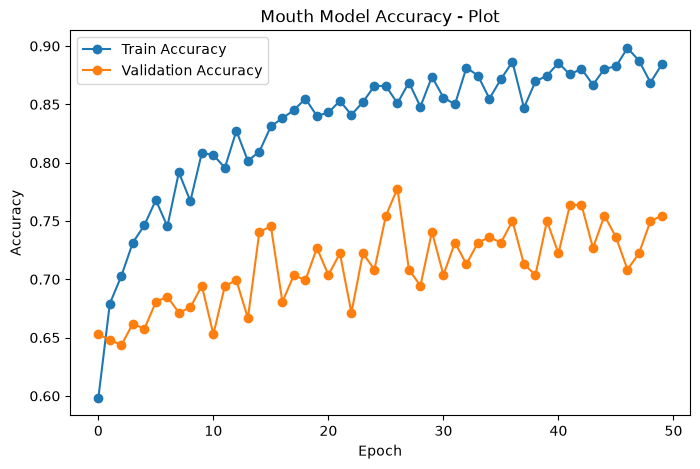

In [145]:
plt.figure(figsize=(8,5))

plt.plot(
    mouth_model_history.history["accuracy"],
    label = "Train Accuracy",
    marker = "o"
)

plt.plot(
    mouth_model_history.history["val_accuracy"],
    label = "Validation Accuracy",
    marker = "o"
)

plt.title("Mouth Model Accuracy - Plot")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()     

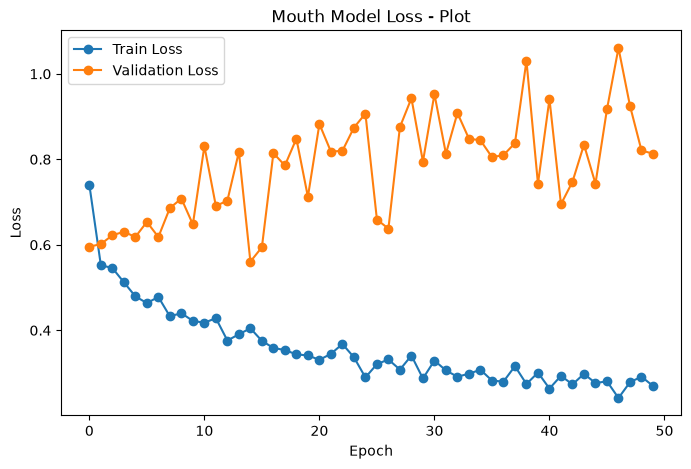

In [146]:
plt.figure(figsize=(8,5))

plt.plot(
    mouth_model_history.history["loss"],
    label = "Train Loss",
    marker = "o"
)

plt.plot(mouth_model_history.history["val_loss"],
         label = "Validation Loss",
    marker = "o"
)

plt.title("Mouth Model Loss - Plot")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()     

---

### Evaluate - Test Data

In [147]:
mouth_test_loss, mouth_test_accuracy = mouth_model.evaluate(mouth_test_dataset)

print("Test Accuracy: ", mouth_test_accuracy)
print("Test Loss: ", mouth_test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7717 - loss: 0.6194
Test Accuracy:  0.7716894745826721
Test Loss:  0.6193704009056091


---

### Prediction - Test Data

In [148]:
mouth_predicted = mouth_model.predict(mouth_test_dataset)

mouth_predicted_classes = np.argmax(mouth_predicted, axis=1)

mouth_predicted_classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1])

In [149]:
mouth_actual_classes = np.concatenate([np.argmax(labels, axis=1) for images, labels in mouth_test_dataset])

mouth_actual_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

---

### Confusion Matrix

In [150]:
mouth_c_matrix = confusion_matrix(
    mouth_actual_classes, 
    mouth_predicted_classes,
)

Text(0, 0.5, 'Actual Label')

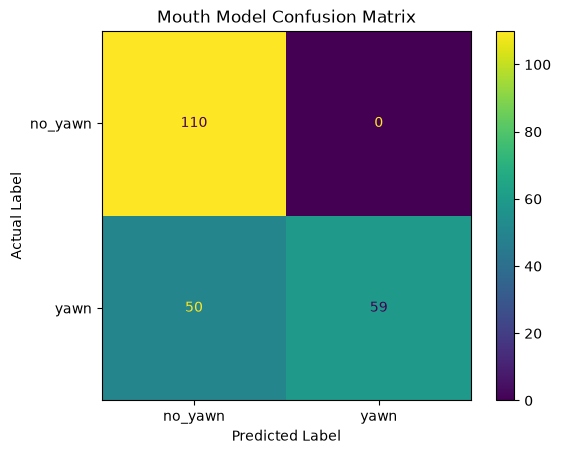

In [151]:
ConfusionMatrixDisplay(
    mouth_c_matrix,
    display_labels=mouth_test_dataset.class_names
).plot()

plt.title("Mouth Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

---

### Classification Report

In [152]:
print(
    classification_report(
        mouth_actual_classes, 
        mouth_predicted_classes, 
        target_names=mouth_test_dataset.class_names
    )
)

              precision    recall  f1-score   support

     no_yawn       0.69      1.00      0.81       110
        yawn       1.00      0.54      0.70       109

    accuracy                           0.77       219
   macro avg       0.84      0.77      0.76       219
weighted avg       0.84      0.77      0.76       219



---

## Accuracy, Loss - Train, Validation, Test

In [153]:
eye_train_accuracy = eye_model_history.history["accuracy"][-1]
eye_train_loss = eye_model_history.history["loss"][-1]

eye_val_accuracy = eye_model_history.history["val_accuracy"][-1]
eye_val_loss = eye_model_history.history["val_loss"][-1]

mouth_train_accuracy = mouth_model_history.history["accuracy"][-1]
mouth_train_loss = mouth_model_history.history["loss"][-1]

mouth_val_accuracy = mouth_model_history.history["val_accuracy"][-1]
mouth_val_loss = mouth_model_history.history["val_loss"][-1]


print("Eye Model")
print(f"Train Accuracy: {eye_train_accuracy:02f} | Loss: {eye_train_loss:02f}")
print(f"Val Accuracy  : {eye_val_accuracy:02f} | Loss: {eye_val_loss:02f}" )
print(f"Test Accuracy : {eye_test_accuracy:02f} | Loss: {eye_test_loss:02f}")
print()
print("Mouth Model")
print(f"Train Accuracy: {mouth_train_accuracy:02f} | Loss: {mouth_train_loss:02f}")
print(f"Val Accuracy  : {mouth_val_accuracy:02f} | Loss: {mouth_val_loss:02f}")
print(f"Test Accuracy : {mouth_test_accuracy:02f} | Loss: {mouth_test_loss:02f}")

Eye Model
Train Accuracy: 0.996063 | Loss: 0.010258
Val Accuracy  : 1.000000 | Loss: 0.001631
Test Accuracy : 0.995455 | Loss: 0.013582

Mouth Model
Train Accuracy: 0.884501 | Loss: 0.269805
Val Accuracy  : 0.754630 | Loss: 0.813158
Test Accuracy : 0.771689 | Loss: 0.619370


---

## Fine Tuning Mouth Model

In [154]:
for i, label in enumerate(base_model_mouth.layers):
    print(i, label.name, label.trainable)

0 input_layer_8 False
1 Conv1 False
2 bn_Conv1 False
3 Conv1_relu False
4 expanded_conv_depthwise False
5 expanded_conv_depthwise_BN False
6 expanded_conv_depthwise_relu False
7 expanded_conv_project False
8 expanded_conv_project_BN False
9 block_1_expand False
10 block_1_expand_BN False
11 block_1_expand_relu False
12 block_1_pad False
13 block_1_depthwise False
14 block_1_depthwise_BN False
15 block_1_depthwise_relu False
16 block_1_project False
17 block_1_project_BN False
18 block_2_expand False
19 block_2_expand_BN False
20 block_2_expand_relu False
21 block_2_depthwise False
22 block_2_depthwise_BN False
23 block_2_depthwise_relu False
24 block_2_project False
25 block_2_project_BN False
26 block_2_add False
27 block_3_expand False
28 block_3_expand_BN False
29 block_3_expand_relu False
30 block_3_pad False
31 block_3_depthwise False
32 block_3_depthwise_BN False
33 block_3_depthwise_relu False
34 block_3_project False
35 block_3_project_BN False
36 block_4_expand False
37 block_

In [155]:
fine_tune_at = 100

for layer in base_model_mouth.layers[fine_tune_at:]:
    layer.trainable = True
    
for layer in base_model_mouth.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

---

### Retraining - Mouth Model

In [156]:
mouth_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.00003),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [157]:
mouth_model_history = mouth_model.fit(
    mouth_train_dataset,
    validation_data = mouth_validation_dataset,
    epochs = 20
)

Epoch 1/20


/home/jeeva/miniconda3/envs/tf-gpu-conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.7680 - loss: 0.5543 - val_accuracy: 0.7917 - val_loss: 0.4862
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.8963 - loss: 0.2702 - val_accuracy: 0.8565 - val_loss: 0.4616
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9131 - loss: 0.1888 - val_accuracy: 0.8750 - val_loss: 0.3562
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9447 - loss: 0.1397 - val_accuracy: 0.8657 - val_loss: 0.4770
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9497 - loss: 0.1458 - val_accuracy: 0.9120 - val_loss: 0.3047
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9576 - loss: 0.1114 - val_accuracy: 0.9028 - val_loss: 0.3096
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9526 - loss: 0.1118 - val_accuracy: 0.9444 - val_loss: 0.1824
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9625 - loss: 0.1077 - val_accuracy: 0.8981 - val

---

### Accuracy, Loss Plot - Mouth Model

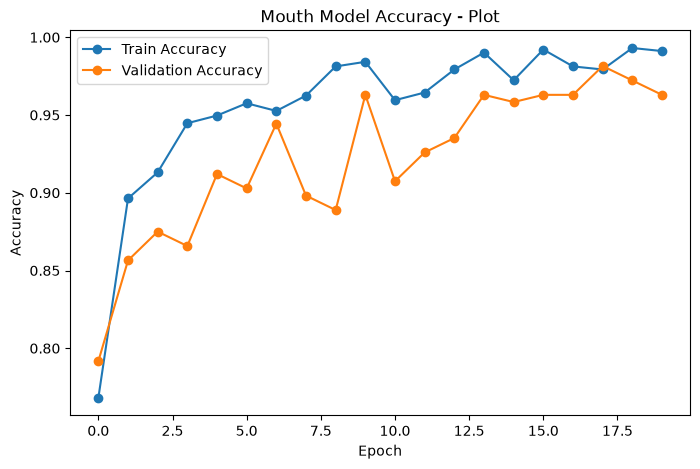

In [158]:
plt.figure(figsize=(8,5))

plt.plot(
    mouth_model_history.history["accuracy"],
    label = "Train Accuracy",
    marker = "o"
)

plt.plot(
    mouth_model_history.history["val_accuracy"],
    label = "Validation Accuracy",
    marker = "o"
)

plt.title("Mouth Model Accuracy - Plot")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()     

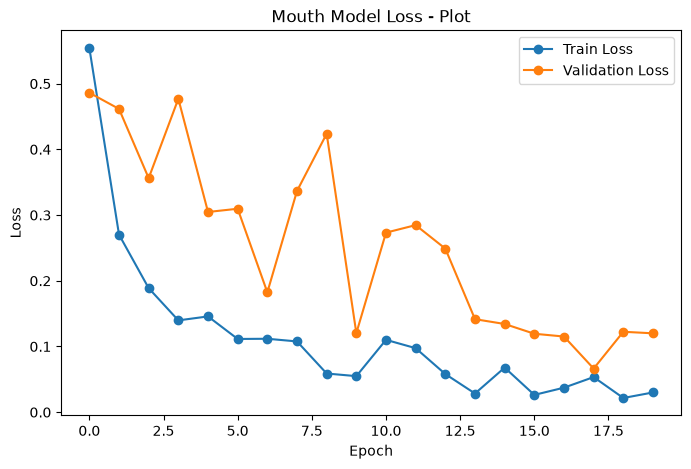

In [159]:
plt.figure(figsize=(8,5))

plt.plot(
    mouth_model_history.history["loss"],
    label = "Train Loss",
    marker = "o"
)

plt.plot(mouth_model_history.history["val_loss"],
         label = "Validation Loss",
    marker = "o"
)

plt.title("Mouth Model Loss - Plot")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()     

---

### Evaluate - Mouth Test Data

In [160]:
mouth_test_loss, mouth_test_accuracy = mouth_model.evaluate(mouth_test_dataset)

print("Test Accuracy: ", mouth_test_accuracy)
print("Test Loss: ", mouth_test_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9817 - loss: 0.0714
Test Accuracy:  0.9817351698875427
Test Loss:  0.07137636840343475


---

### Prediction - Mouth Test Data

In [161]:
mouth_predicted = mouth_model.predict(mouth_test_dataset)

mouth_predicted_classes = np.argmax(mouth_predicted, axis=1)

mouth_predicted_classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [162]:
mouth_actual_classes = np.concatenate([np.argmax(labels, axis=1) for images, labels in mouth_test_dataset])

mouth_actual_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

----

### Confusion Matrix

In [163]:
mouth_c_matrix = confusion_matrix(
    mouth_actual_classes, 
    mouth_predicted_classes,
)

Text(0, 0.5, 'Actual Label')

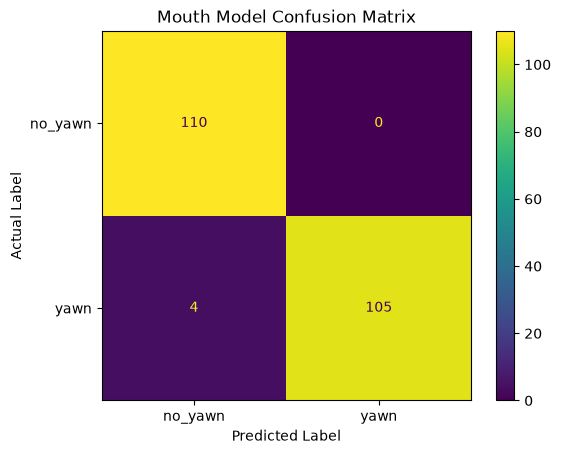

In [164]:
ConfusionMatrixDisplay(
    mouth_c_matrix,
    display_labels=mouth_test_dataset.class_names
).plot()

plt.title("Mouth Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

---

### Classification Report

In [165]:
print(
    classification_report(
        mouth_actual_classes, 
        mouth_predicted_classes, 
        target_names=mouth_test_dataset.class_names
    )
)

              precision    recall  f1-score   support

     no_yawn       0.96      1.00      0.98       110
        yawn       1.00      0.96      0.98       109

    accuracy                           0.98       219
   macro avg       0.98      0.98      0.98       219
weighted avg       0.98      0.98      0.98       219



---

## Accuracy, Loss - Train, Validation, Test

In [166]:
eye_train_accuracy = eye_model_history.history["accuracy"][-1]
eye_train_loss = eye_model_history.history["loss"][-1]

eye_val_accuracy = eye_model_history.history["val_accuracy"][-1]
eye_val_loss = eye_model_history.history["val_loss"][-1]

mouth_train_accuracy = mouth_model_history.history["accuracy"][-1]
mouth_train_loss = mouth_model_history.history["loss"][-1]

mouth_val_accuracy = mouth_model_history.history["val_accuracy"][-1]
mouth_val_loss = mouth_model_history.history["val_loss"][-1]


print("Eye Model")
print(f"Train Accuracy: {eye_train_accuracy:02f} | Loss: {eye_train_loss:02f}")
print(f"Val Accuracy  : {eye_val_accuracy:02f} | Loss: {eye_val_loss:02f}" )
print(f"Test Accuracy : {eye_test_accuracy:02f} | Loss: {eye_test_loss:02f}")
print()
print("Mouth Model")
print(f"Train Accuracy: {mouth_train_accuracy:02f} | Loss: {mouth_train_loss:02f}")
print(f"Val Accuracy  : {mouth_val_accuracy:02f} | Loss: {mouth_val_loss:02f}")
print(f"Test Accuracy : {mouth_test_accuracy:02f} | Loss: {mouth_test_loss:02f}")

Eye Model
Train Accuracy: 0.996063 | Loss: 0.010258
Val Accuracy  : 1.000000 | Loss: 0.001631
Test Accuracy : 0.995455 | Loss: 0.013582

Mouth Model
Train Accuracy: 0.991116 | Loss: 0.030044
Val Accuracy  : 0.962963 | Loss: 0.120043
Test Accuracy : 0.981735 | Loss: 0.071376


---

# Storing Model

In [167]:
eye_model.save("../encoded_files/eye_mobilenetv2_model.keras")

In [168]:
mouth_model.save("../encoded_files/mouth_mobilenetv2_model.keras")

---

# 3-Level Fatigue Classification - Alert, Mild and Severe Fatigue

In [169]:
eye_classes = eye_train_dataset.class_names
mouth_classes = mouth_train_dataset.class_names

In [170]:
print("Eye Classes  : ", eye_classes)
print("Mouth Classes: ",  mouth_classes)

Eye Classes  :  ['closed', 'open']
Mouth Classes:  ['no_yawn', 'yawn']


In [171]:
def fatigue_classification(eye_state, mouth_state):
    
    if eye_state == "closed":
        return 2, "Severe Fatigue"
    
    elif mouth_state == "yawn":
        return 1, "Mild Fatigue"
    
    else:
        return 0, "Alert"

In [172]:
eye_predicted_labels =  [eye_classes[i] for i in eye_predicted_classes]

mouth_predicted_labels = [mouth_classes[i] for i in mouth_predicted_classes]

print("Eye Prediction: ")

print("Total: ", len(eye_predicted_labels))

print(eye_predicted_labels, "\n")

print("Mouth Prediction: ")

print("Total: ", len(mouth_predicted_labels))

print(mouth_predicted_labels)

Eye Prediction: 
Total:  220
['closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 'closed', 

#

In [274]:
eye_predicted_labels = eye_predicted_labels[:len(mouth_predicted_labels)]

random.seed(41)

random.shuffle(eye_predicted_labels)
random.shuffle(mouth_predicted_labels)

print("Eye Prediction: ")

print("Total: ", len(eye_predicted_labels))

print(eye_predicted_labels, "\n")

print("Mouth Prediction: ")

print("Total: ", len(mouth_predicted_labels))

print(mouth_predicted_labels)

Eye Prediction: 
Total:  219
['closed', 'open', 'closed', 'closed', 'open', 'open', 'open', 'closed', 'closed', 'open', 'closed', 'open', 'closed', 'open', 'closed', 'open', 'closed', 'closed', 'closed', 'open', 'closed', 'closed', 'open', 'open', 'open', 'open', 'open', 'closed', 'open', 'closed', 'open', 'closed', 'closed', 'open', 'closed', 'closed', 'closed', 'open', 'open', 'open', 'closed', 'closed', 'open', 'closed', 'open', 'open', 'open', 'closed', 'closed', 'open', 'closed', 'closed', 'open', 'closed', 'open', 'closed', 'open', 'closed', 'closed', 'open', 'closed', 'closed', 'closed', 'open', 'open', 'closed', 'closed', 'open', 'open', 'closed', 'closed', 'open', 'open', 'open', 'closed', 'closed', 'open', 'open', 'closed', 'open', 'open', 'closed', 'closed', 'open', 'closed', 'open', 'closed', 'closed', 'open', 'closed', 'closed', 'closed', 'open', 'open', 'closed', 'open', 'open', 'open', 'open', 'closed', 'open', 'open', 'open', 'closed', 'open', 'open', 'open', 'open', 'o

In [275]:
fatigue_stages = []

fatigue_labels = []

for eye_state, mouth_state in zip(eye_predicted_labels, mouth_predicted_labels):
    
    stage, label = fatigue_classification(eye_state, mouth_state)
    
    fatigue_stages.append(stage)
    
    fatigue_labels.append(label)
    

---

# Create Dataframe - Eye State, Mouth State and Fatigue Stage

In [276]:
import pandas as pd

In [277]:
frame_numbers = np.arange(1, len(fatigue_labels)+1)

In [278]:
fatigue_df = pd.DataFrame({
    "Frame" : frame_numbers,
    "Eye State" : eye_predicted_labels,
    "Mouth State": mouth_predicted_labels,
    "Fatigue Stage": fatigue_stages,
    "Fatigue Labels": fatigue_labels
})

In [279]:
fatigue_df.head()

,Frame,Eye State,Mouth State,Fatigue Stage,Fatigue Labels
0,1,closed,yawn,2,Severe Fatigue
1,2,open,no_yawn,0,Alert
2,3,closed,no_yawn,2,Severe Fatigue
3,4,closed,yawn,2,Severe Fatigue
4,5,open,yawn,1,Mild Fatigue


In [280]:
frames_per_minute = 30

fatigue_df["Time (minutes)"] = (fatigue_df["Frame"]-1) // frames_per_minute+1

fatigue_df.head()

,Frame,Eye State,Mouth State,Fatigue Stage,Fatigue Labels,Time (minutes)
0,1,closed,yawn,2,Severe Fatigue,1
1,2,open,no_yawn,0,Alert,1
2,3,closed,no_yawn,2,Severe Fatigue,1
3,4,closed,yawn,2,Severe Fatigue,1
4,5,open,yawn,1,Mild Fatigue,1


In [281]:
minute_most_occur = pd.DataFrame(
    (fatigue_df.groupby("Time (minutes)")["Fatigue Stage"].agg(lambda x: x.mode()[0])).reset_index()
)

minute_most_occur

,Time (minutes),Fatigue Stage
0,1,2
1,2,2
2,3,2
3,4,1
4,5,1
5,6,2
6,7,2
7,8,2


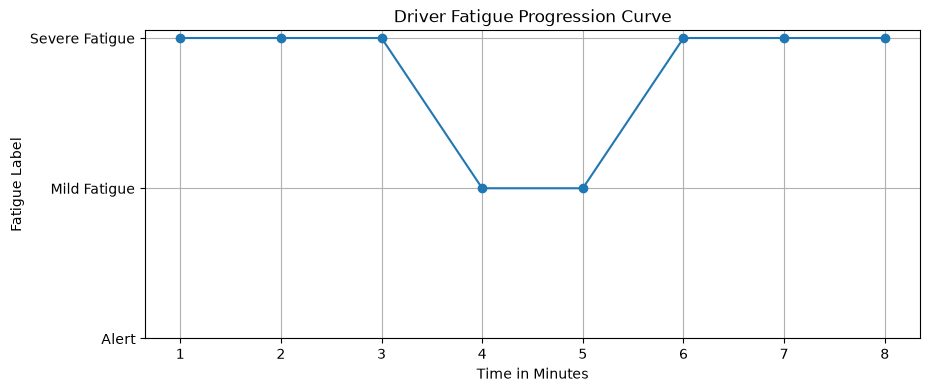

In [282]:
plt.figure(figsize=(10,4))

plt.plot(
    minute_most_occur["Time (minutes)"],
    minute_most_occur["Fatigue Stage"],
    marker = "o"
)

plt.grid(True)

plt.yticks(
    [0,1,2],
    ["Alert", "Mild Fatigue", "Severe Fatigue"]
)

plt.title("Driver Fatigue Progression Curve")
plt.xlabel("Time in Minutes")
plt.ylabel("Fatigue Label")

plt.show()

#

In [283]:
fatigue_label_names = {
    0:"Alert",
    1:"Mild Fatigue",
    2:"Severe Fatigue"
}

previous_stage = None

for minute, stage in minute_most_occur.itertuples(index=False):
    
    if (previous_stage is not None) and (stage != previous_stage):
        
        print(f"Minute {minute}: {fatigue_label_names[previous_stage]} -> {fatigue_label_names[stage]}")
        
    previous_stage = stage
    


Minute 4: Severe Fatigue -> Mild Fatigue
Minute 6: Mild Fatigue -> Severe Fatigue


---